In [3]:
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv("vehicle_price_prediction.csv")
df.head()

,make,model,year,mileage,engine_hp,transmission,fuel_type,drivetrain,body_type,exterior_color,interior_color,owner_count,accident_history,seller_type,condition,trim,vehicle_age,mileage_per_year,brand_popularity,price
0,Volkswagen,Jetta,2016,183903,173,Manual,Electric,RWD,Sedan,Blue,Brown,5,NaN,Dealer,Excellent,EX,9,20433.666667,0.040054,7208.52
1,Lexus,RX,2010,236643,352,Manual,Gasoline,FWD,Sedan,Silver,Beige,5,Minor,Dealer,Good,LX,15,15776.200000,0.039921,6911.81
2,Subaru,Crosstrek,2016,103199,188,Automatic,Diesel,AWD,Sedan,Silver,Beige,5,NaN,Dealer,Excellent,Touring,9,11466.555556,0.040230,11915.63
3,Cadillac,Lyriq,2016,118889,338,Manual,Gasoline,AWD,SUV,Black,Gray,3,NaN,Private,Good,Base,9,13209.888889,0.039847,25984.79
4,Toyota,Highlander,2018,204170,196,Manual,Diesel,FWD,Sedan,Red,Brown,5,Minor,Dealer,Excellent,Sport,7,29167.142857,0.039627,8151.30


In [5]:
df.shape
df.columns

Index(['make', 'model', 'year', 'mileage', 'engine_hp', 'transmission',
       'fuel_type', 'drivetrain', 'body_type', 'exterior_color',
       'interior_color', 'owner_count', 'accident_history', 'seller_type',
       'condition', 'trim', 'vehicle_age', 'mileage_per_year',
       'brand_popularity', 'price'],
      dtype='object')

In [6]:
train_df = df.iloc[0:70001]
val_df = df.iloc[70001:85001]
test_df = df.iloc[85001:100000]

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Training: (70001, 20)
Validation: (15000, 20)
Test: (14999, 20)


In [7]:
df["condition"].value_counts()

condition
Good         499683
Excellent    400373
Fair          99944
Name: count, dtype: int64

In [8]:
def gini_impurity(y, n_classes):
    counts = np.bincount(y, minlength=n_classes)
    probabilities = counts / len(y)
    return 1 - np.sum(probabilities ** 2)


def accuracy(y_true, y_pred):
    return np.mean(np.array(y_true) == np.array(y_pred))


In [9]:
class DecisionTreeScratch:
    def __init__(self, max_depth=8, min_samples_leaf=5, max_features=None, random_state=None):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)

    def fit(self, X, y):
        self.features = sorted(list(X.columns))  # alphabetical order for tie-breaking
        self.classes = sorted(pd.Series(y).unique())
        self.class_to_int = {c: i for i, c in enumerate(self.classes)}
        self.int_to_class = {i: c for c, i in self.class_to_int.items()}
        self.n_classes = len(self.classes)

        y_encoded = pd.Series(y).map(self.class_to_int).to_numpy()

        self.feature_types = {}
        self.fill_values = {}

        X_fixed = X.copy()

        for col in self.features:
            if pd.api.types.is_numeric_dtype(X_fixed[col]):
                self.feature_types[col] = "numeric"
                fill_value = X_fixed[col].median()
                self.fill_values[col] = fill_value
                X_fixed[col] = X_fixed[col].fillna(fill_value).astype(float)
            else:
                self.feature_types[col] = "categorical"
                self.fill_values[col] = "__MISSING__"
                X_fixed[col] = X_fixed[col].fillna("__MISSING__").astype(str)

        self.tree = self._build_tree(X_fixed, y_encoded, depth=0)
        return self

    def _majority_class(self, y):
        counts = np.bincount(y, minlength=self.n_classes)
        return np.argmax(counts)

    def _choose_features(self):
        if self.max_features is None:
            return self.features

        if self.max_features == "sqrt":
            k = max(1, int(np.sqrt(len(self.features))))
        elif isinstance(self.max_features, int):
            k = min(self.max_features, len(self.features))
        else:
            k = len(self.features)

        chosen = self.rng.choice(self.features, size=k, replace=False)
        return sorted(chosen)

    def _best_split(self, X, y):
        parent_gini = gini_impurity(y, self.n_classes)

        best_gain = 0
        best_feature = None
        best_value = None
        best_is_numeric = None
        best_left_mask = None

        for feature in self._choose_features():
            values = X[feature].to_numpy()

            if self.feature_types[feature] == "numeric":
                order = np.argsort(values)
                sorted_values = values[order]

                for i in range(self.min_samples_leaf - 1, len(y) - self.min_samples_leaf):
                    if sorted_values[i] == sorted_values[i + 1]:
                        continue

                    threshold = (sorted_values[i] + sorted_values[i + 1]) / 2

                    left_mask = values <= threshold
                    right_mask = ~left_mask

                    if left_mask.sum() < self.min_samples_leaf:
                        continue

                    if right_mask.sum() < self.min_samples_leaf:
                        continue

                    left_gini = gini_impurity(y[left_mask], self.n_classes)
                    right_gini = gini_impurity(y[right_mask], self.n_classes)

                    weighted_gini = (
                        left_mask.sum() / len(y) * left_gini
                        + right_mask.sum() / len(y) * right_gini
                    )

                    gain = parent_gini - weighted_gini

                    if gain > best_gain:
                        best_gain = gain
                        best_feature = feature
                        best_value = threshold
                        best_is_numeric = True
                        best_left_mask = left_mask

            else:
                categories = sorted(pd.Series(values).unique())

                for category in categories:
                    left_mask = values == category
                    right_mask = ~left_mask

                    if left_mask.sum() < self.min_samples_leaf:
                        continue

                    if right_mask.sum() < self.min_samples_leaf:
                        continue

                    left_gini = gini_impurity(y[left_mask], self.n_classes)
                    right_gini = gini_impurity(y[right_mask], self.n_classes)

                    weighted_gini = (
                        left_mask.sum() / len(y) * left_gini
                        + right_mask.sum() / len(y) * right_gini
                    )

                    gain = parent_gini - weighted_gini

                    if gain > best_gain:
                        best_gain = gain
                        best_feature = feature
                        best_value = category
                        best_is_numeric = False
                        best_left_mask = left_mask

        if best_feature is None:
            return None

        return best_feature, best_value, best_is_numeric, best_left_mask, best_gain

    def _build_tree(self, X, y, depth):
        prediction = self._majority_class(y)

        if len(np.unique(y)) == 1:
            return {"type": "leaf", "prediction": prediction}

        if self.max_depth is not None and depth >= self.max_depth:
            return {"type": "leaf", "prediction": prediction}

        if len(y) < 2 * self.min_samples_leaf:
            return {"type": "leaf", "prediction": prediction}

        split = self._best_split(X, y)

        if split is None:
            return {"type": "leaf", "prediction": prediction}

        feature, value, is_numeric, left_mask, gain = split

        if gain <= 0:
            return {"type": "leaf", "prediction": prediction}

        right_mask = ~left_mask

        return {
            "type": "node",
            "feature": feature,
            "value": value,
            "is_numeric": is_numeric,
            "left": self._build_tree(X[left_mask], y[left_mask], depth + 1),
            "right": self._build_tree(X[right_mask], y[right_mask], depth + 1)
        }

    def _prepare_X(self, X):
        X_fixed = X.copy()

        for col in self.features:
            if self.feature_types[col] == "numeric":
                X_fixed[col] = X_fixed[col].fillna(self.fill_values[col]).astype(float)
            else:
                X_fixed[col] = X_fixed[col].fillna("__MISSING__").astype(str)

        return X_fixed[self.features]

    def _predict_one(self, row, node):
        if node["type"] == "leaf":
            return self.int_to_class[node["prediction"]]

        feature = node["feature"]

        if node["is_numeric"]:
            if row[feature] <= node["value"]:
                return self._predict_one(row, node["left"])
            return self._predict_one(row, node["right"])

        if row[feature] == node["value"]:
            return self._predict_one(row, node["left"])
        return self._predict_one(row, node["right"])

    def predict(self, X):
        X_fixed = self._prepare_X(X)
        predictions = []

        for _, row in X_fixed.iterrows():
            predictions.append(self._predict_one(row, self.tree))

        return np.array(predictions)

In [10]:
target_col = "condition"

X_train = train_df.drop(columns=["condition", "price"])
y_train = train_df[target_col]

X_val = val_df.drop(columns=["condition", "price"])
y_val = val_df[target_col]

X_test = test_df.drop(columns=["condition", "price"])
y_test = test_df[target_col]

dt_model = DecisionTreeScratch(
    max_depth=8,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_val_pred = dt_model.predict(X_val)

print("Decision Tree Validation Accuracy:", accuracy(y_val, dt_val_pred))

Decision Tree Validation Accuracy: 0.4961333333333333


In [11]:
class RandomForestClassifierScratch:
    def __init__(self, n_estimators=3, max_depth=8, min_samples_leaf=5,
                 max_features="sqrt", sample_ratio=0.7, random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.sample_ratio = sample_ratio
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples = len(X)
        sample_size = int(n_samples * self.sample_ratio)

        for i in range(self.n_estimators):
            sample_indices = self.rng.choice(
                n_samples,
                size=sample_size,
                replace=True
            )

            X_sample = X.iloc[sample_indices]
            y_sample = y.iloc[sample_indices]

            tree = DecisionTreeScratch(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features,
                random_state=self.random_state + i
            )

            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

            print(f"Finished tree {i + 1}/{self.n_estimators}")

        return self

    def predict(self, X):
        all_predictions = np.array([tree.predict(X) for tree in self.trees])

        final_predictions = []

        for predictions_for_one_row in all_predictions.T:
            values, counts = np.unique(predictions_for_one_row, return_counts=True)
            final_predictions.append(values[np.argmax(counts)])

        return np.array(final_predictions)

In [12]:
rf_classifier = RandomForestClassifierScratch(
    n_estimators=3,
    max_depth=8,
    min_samples_leaf=5,
    max_features="sqrt",
    sample_ratio=0.7,
    random_state=42
)

rf_classifier.fit(X_train, y_train)

rf_val_pred = rf_classifier.predict(X_val)

print("Random Forest Classifier Validation Accuracy:", accuracy(y_val, rf_val_pred))


Finished tree 1/3
Finished tree 2/3
Finished tree 3/3
Random Forest Classifier Validation Accuracy: 0.49833333333333335


In [13]:
def ssr(y):
    y = np.array(y, dtype=float)
    mean_y = np.mean(y)
    return np.sum((y - mean_y) ** 2)


def mse(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)

In [14]:
class DecisionTreeRegressorScratch:
    def __init__(self, max_depth=8, min_samples_leaf=5, max_features=None,
                 max_thresholds=40, random_state=None):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.max_thresholds = max_thresholds
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)

    def fit(self, X, y):
        # Sort features alphabetically for tie-breaking
        self.features = sorted(list(X.columns))

        self.feature_types = {}
        self.fill_values = {}

        X_fixed = X.copy()
        y_fixed = pd.Series(y).astype(float).to_numpy()

        for col in self.features:
            if pd.api.types.is_numeric_dtype(X_fixed[col]):
                self.feature_types[col] = "numeric"
                fill_value = X_fixed[col].median()
                self.fill_values[col] = fill_value
                X_fixed[col] = X_fixed[col].fillna(fill_value).astype(float)
            else:
                self.feature_types[col] = "categorical"
                self.fill_values[col] = "__MISSING__"
                X_fixed[col] = X_fixed[col].fillna("__MISSING__").astype(str)

        self.tree = self._build_tree(X_fixed, y_fixed, depth=0)
        return self

    def _leaf_value(self, y):
        return np.mean(y)

    def _choose_features(self):
        if self.max_features is None:
            return self.features

        if self.max_features == "sqrt":
            k = max(1, int(np.sqrt(len(self.features))))
        elif isinstance(self.max_features, int):
            k = min(self.max_features, len(self.features))
        else:
            k = len(self.features)

        chosen = self.rng.choice(self.features, size=k, replace=False)
        return sorted(chosen)

    def _numeric_thresholds(self, values):
        unique_values = np.unique(values)

        if len(unique_values) <= 1:
            return []

        thresholds = (unique_values[:-1] + unique_values[1:]) / 2

        # To reduce runtime on large data
        if len(thresholds) > self.max_thresholds:
            percentiles = np.linspace(0, 100, self.max_thresholds + 2)[1:-1]
            thresholds = np.percentile(values, percentiles)
            thresholds = np.unique(thresholds)

        return thresholds

    def _best_split(self, X, y):
        parent_ssr = ssr(y)

        best_gain = 0
        best_feature = None
        best_value = None
        best_is_numeric = None
        best_left_mask = None

        for feature in self._choose_features():
            values = X[feature].to_numpy()

            if self.feature_types[feature] == "numeric":
                thresholds = self._numeric_thresholds(values)

                for threshold in thresholds:
                    left_mask = values <= threshold
                    right_mask = ~left_mask

                    if left_mask.sum() < self.min_samples_leaf:
                        continue

                    if right_mask.sum() < self.min_samples_leaf:
                        continue

                    left_y = y[left_mask]
                    right_y = y[right_mask]

                    child_ssr = ssr(left_y) + ssr(right_y)
                    gain = parent_ssr - child_ssr

                    # Strict > keeps the first alphabetical feature in case of tie
                    if gain > best_gain:
                        best_gain = gain
                        best_feature = feature
                        best_value = threshold
                        best_is_numeric = True
                        best_left_mask = left_mask

            else:
                categories = sorted(pd.Series(values).unique())

                for category in categories:
                    left_mask = values == category
                    right_mask = ~left_mask

                    if left_mask.sum() < self.min_samples_leaf:
                        continue

                    if right_mask.sum() < self.min_samples_leaf:
                        continue

                    left_y = y[left_mask]
                    right_y = y[right_mask]

                    child_ssr = ssr(left_y) + ssr(right_y)
                    gain = parent_ssr - child_ssr

                    # Strict > keeps the first alphabetical feature in case of tie
                    if gain > best_gain:
                        best_gain = gain
                        best_feature = feature
                        best_value = category
                        best_is_numeric = False
                        best_left_mask = left_mask

        if best_feature is None:
            return None

        return best_feature, best_value, best_is_numeric, best_left_mask, best_gain

    def _build_tree(self, X, y, depth):
        prediction = self._leaf_value(y)

        if self.max_depth is not None and depth >= self.max_depth:
            return {"type": "leaf", "prediction": prediction}

        if len(y) < 2 * self.min_samples_leaf:
            return {"type": "leaf", "prediction": prediction}

        split = self._best_split(X, y)

        if split is None:
            return {"type": "leaf", "prediction": prediction}

        feature, value, is_numeric, left_mask, gain = split

        if gain <= 0:
            return {"type": "leaf", "prediction": prediction}

        right_mask = ~left_mask

        return {
            "type": "node",
            "feature": feature,
            "value": value,
            "is_numeric": is_numeric,
            "left": self._build_tree(X[left_mask], y[left_mask], depth + 1),
            "right": self._build_tree(X[right_mask], y[right_mask], depth + 1)
        }

    def _prepare_X(self, X):
        X_fixed = X.copy()

        for col in self.features:
            if self.feature_types[col] == "numeric":
                X_fixed[col] = X_fixed[col].fillna(self.fill_values[col]).astype(float)
            else:
                X_fixed[col] = X_fixed[col].fillna("__MISSING__").astype(str)

        return X_fixed[self.features]

    def _predict_one(self, row, node):
        if node["type"] == "leaf":
            return node["prediction"]

        feature = node["feature"]

        if node["is_numeric"]:
            if row[feature] <= node["value"]:
                return self._predict_one(row, node["left"])
            return self._predict_one(row, node["right"])

        if row[feature] == node["value"]:
            return self._predict_one(row, node["left"])
        return self._predict_one(row, node["right"])

    def predict(self, X):
        X_fixed = self._prepare_X(X)
        predictions = []

        for _, row in X_fixed.iterrows():
            predictions.append(self._predict_one(row, self.tree))

        return np.array(predictions)

In [15]:
target_col = "price"

X_train_reg = train_df.drop(columns=["condition", "price"])
y_train_reg = train_df[target_col]

X_val_reg = val_df.drop(columns=["condition", "price"])
y_val_reg = val_df[target_col]

X_test_reg = test_df.drop(columns=["condition", "price"])
y_test_reg = test_df[target_col]

dt_regressor = DecisionTreeRegressorScratch(
    max_depth=8,
    min_samples_leaf=5,
    max_thresholds=40,
    random_state=42
)

dt_regressor.fit(X_train_reg, y_train_reg)

dt_reg_val_pred = dt_regressor.predict(X_val_reg)

print("Decision Tree Regressor Validation MSE:", mse(y_val_reg, dt_reg_val_pred))


Decision Tree Regressor Validation MSE: 11050001.651596187


In [16]:
class RandomForestRegressorScratch:
    def __init__(self, n_estimators=3, max_depth=8, min_samples_leaf=5,
                 max_features="sqrt", sample_ratio=0.7, max_thresholds=40,
                 random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.sample_ratio = sample_ratio
        self.max_thresholds = max_thresholds
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        n_samples = len(X)
        sample_size = int(n_samples * self.sample_ratio)

        for i in range(self.n_estimators):
            sample_indices = self.rng.choice(
                n_samples,
                size=sample_size,
                replace=True
            )

            X_sample = X.iloc[sample_indices]
            y_sample = y.iloc[sample_indices]

            tree = DecisionTreeRegressorScratch(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features,
                max_thresholds=self.max_thresholds,
                random_state=self.random_state + i
            )

            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

            print(f"Finished regressor tree {i + 1}/{self.n_estimators}")

        return self

    def predict(self, X):
        all_predictions = np.array([tree.predict(X) for tree in self.trees])

        # Required for Random Forest Regressor:
        # final prediction = average of all trees' predictions
        return np.mean(all_predictions, axis=0)

### Runtime Optimization

To improve runtime efficiency, threshold sampling was used instead of checking all possible thresholds for every numeric feature.

Specifically, the implementation limits the number of checked thresholds using:
`max_thresholds = 40`

This optimization reduces training time while still maintaining good model performance.

In [17]:
rf_regressor = RandomForestRegressorScratch(
    n_estimators=3,
    max_depth=8,
    min_samples_leaf=5,
    max_features="sqrt",
    sample_ratio=0.7,
    max_thresholds=40,
    random_state=42
)

rf_regressor.fit(X_train_reg, y_train_reg)

rf_reg_val_pred = rf_regressor.predict(X_val_reg)

rf_reg_mse = mse(y_val_reg, rf_reg_val_pred)
rf_reg_rmse = np.sqrt(rf_reg_mse)

print("Random Forest Regressor Validation MSE:", rf_reg_mse)
print("Random Forest Regressor Validation RMSE:", rf_reg_rmse)

Finished regressor tree 1/3
Finished regressor tree 2/3
Finished regressor tree 3/3
Random Forest Regressor Validation MSE: 14537039.973467829
Random Forest Regressor Validation RMSE: 3812.747037697076


In [18]:
print("========== Section A Summary ==========")
print("Decision Tree Classifier Validation Accuracy:", accuracy(y_val, dt_val_pred))
print("Random Forest Classifier Validation Accuracy:", accuracy(y_val, rf_val_pred))

dt_reg_mse = mse(y_val_reg, dt_reg_val_pred)
dt_reg_rmse = np.sqrt(dt_reg_mse)

print("Decision Tree Regressor Validation MSE:", dt_reg_mse)
print("Decision Tree Regressor Validation RMSE:", dt_reg_rmse)

print("Random Forest Regressor Validation MSE:", rf_reg_mse)
print("Random Forest Regressor Validation RMSE:", rf_reg_rmse)


# ======== Test Evaluation ========

# Classification Test
dt_test_pred = dt_model.predict(X_test)
rf_test_pred = rf_classifier.predict(X_test)

print("Decision Tree Classifier Test Accuracy:",
      accuracy(y_test, dt_test_pred))

print("Random Forest Classifier Test Accuracy:",
      accuracy(y_test, rf_test_pred))


# Regression Test
dt_reg_test_pred = dt_regressor.predict(X_test_reg)
rf_reg_test_pred = rf_regressor.predict(X_test_reg)

dt_test_mse = mse(y_test_reg, dt_reg_test_pred)
rf_test_mse = mse(y_test_reg, rf_reg_test_pred)

print("Decision Tree Regressor Test MSE:", dt_test_mse)
print("Decision Tree Regressor Test RMSE:", np.sqrt(dt_test_mse))

print("Random Forest Regressor Test MSE:", rf_test_mse)
print("Random Forest Regressor Test RMSE:", np.sqrt(rf_test_mse))

========== Section A Summary ==========
Decision Tree Classifier Validation Accuracy: 0.4961333333333333
Random Forest Classifier Validation Accuracy: 0.49833333333333335
Decision Tree Regressor Validation MSE: 11050001.651596187
Decision Tree Regressor Validation RMSE: 3324.1542761424575
Random Forest Regressor Validation MSE: 14537039.973467829
Random Forest Regressor Validation RMSE: 3812.747037697076
Decision Tree Classifier Test Accuracy: 0.4994332955530369
Random Forest Classifier Test Accuracy: 0.5019667977865191
Decision Tree Regressor Test MSE: 10843558.04765065
Decision Tree Regressor Test RMSE: 3292.9558223047343
Random Forest Regressor Test MSE: 14326357.310213478
Random Forest Regressor Test RMSE: 3785.01747819128


### Section B - Data Preparation

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
original_df = df.copy()

In [21]:
print("Missing values before handling:")
print(original_df.isnull().sum())

print("Total missing values:")
print(original_df.isnull().sum().sum())

Missing values before handling:
make                     0
model                    0
year                     0
mileage                  0
engine_hp                0
transmission             0
fuel_type                0
drivetrain               0
body_type                0
exterior_color           0
interior_color           0
owner_count              0
accident_history    750133
seller_type              0
condition                0
trim                     0
vehicle_age              0
mileage_per_year         0
brand_popularity         0
price                    0
dtype: int64
Total missing values:
750133


In [22]:
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

### Missing Values Handling

Numerical features were filled using the median because it is robust to outliers.

Categorical features were filled using the mode since it represents the most common category.

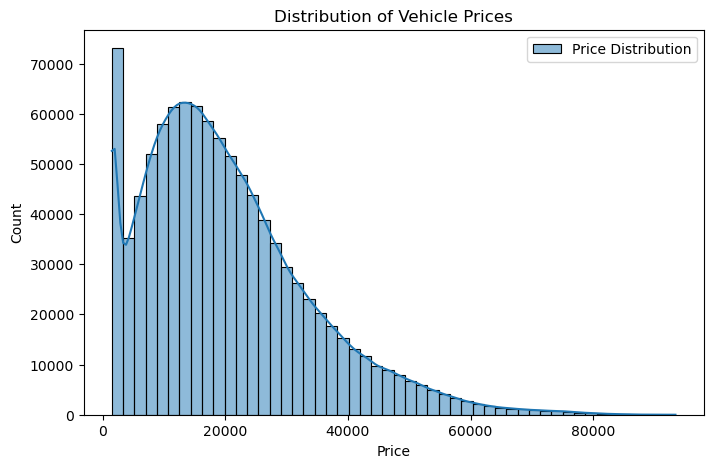

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50, kde=True,
             label="Price Distribution")

plt.legend()
plt.title("Distribution of Vehicle Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

This histogram was selected to visualize the distribution of vehicle prices and detect skewness and possible outliers.
The plot shows that the price distribution is right-skewed, meaning that most vehicles are listed at relatively low prices while a smaller number of vehicles have very high prices.

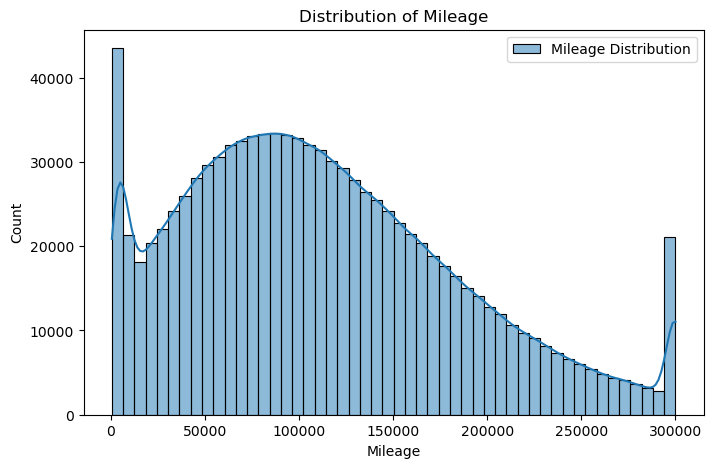

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(
    df["mileage"],
    bins=50,
    kde=True,
    label="Mileage Distribution"
)

plt.legend()
plt.title("Distribution of Mileage")
plt.xlabel("Mileage")
plt.ylabel("Count")

plt.show()

This histogram was selected to visualize the mileage distribution and detect repeated values and possible anomalies.
The graph reveals a concentration of repeated mileage values around 300000 km,
which may indicate rounded values or data acquisition artifacts.

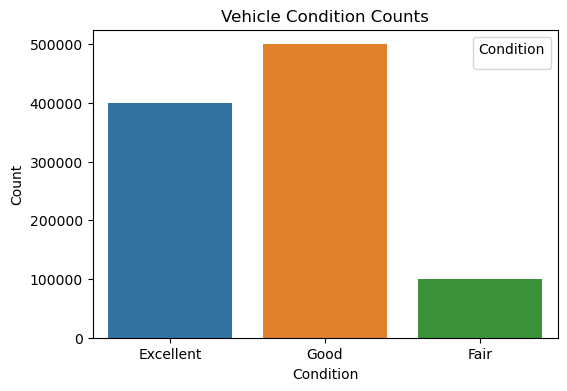

In [25]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x=df["condition"],
    hue=df["condition"]
)

plt.title("Vehicle Condition Counts")
plt.xlabel("Condition")
plt.ylabel("Count")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Condition")

plt.show()


This countplot was used to inspect the balance between the target classes.

In [26]:
Q1_price = df["price"].quantile(0.25)
Q3_price = df["price"].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

price_outliers = df[(df["price"] < lower_price) |
                    (df["price"] > upper_price)]

print("Price outliers:", len(price_outliers))


Price outliers: 25524


In [27]:
Q1_mileage = df["mileage"].quantile(0.25)
Q3_mileage = df["mileage"].quantile(0.75)

IQR_mileage = Q3_mileage - Q1_mileage

lower_mileage = Q1_mileage - 1.5 * IQR_mileage
upper_mileage = Q3_mileage + 1.5 * IQR_mileage

mileage_outliers = df[(df["mileage"] < lower_mileage) |
                      (df["mileage"] > upper_mileage)]

print("Mileage outliers:", len(mileage_outliers))

Mileage outliers: 0


### Artifact Analysis

The price column contains a floor effect where many values are exactly 1500 USD.

Additionally, mileage contains repeated values such as 300000 km, which may indicate rounded values or data acquisition artifacts.

These values were not removed because they may still represent real vehicles and removing them could distort the dataset distribution.

In [28]:
price_1500_count = (df["price"] == 1500).sum()

price_1500_percent = (
    price_1500_count / len(df)
) * 100

print("Vehicles priced exactly 1500:",
      price_1500_count)

print("Percentage:",
      round(price_1500_percent, 2), "%")

Vehicles priced exactly 1500: 46984
Percentage: 4.7 %


In [29]:
mileage_300k_count = (
    df["mileage"] == 300000
).sum()

mileage_300k_percent = (
    mileage_300k_count / len(df)
) * 100

print("Vehicles with mileage 300000:",
      mileage_300k_count)

print("Percentage:",
      round(mileage_300k_percent, 2), "%")

Vehicles with mileage 300000: 18534
Percentage: 1.85 %


### Outlier Threshold Justification

The IQR method was selected because it is robust to skewed distributions and extreme values.

Outliers were identified using the standard 1.5 × IQR rule.

The detected outliers were inspected manually before deciding whether to remove them. Most were kept because they likely represent real market values rather than invalid observations.

Removing these entries did not significantly change the overall distribution
of the dataset, therefore most observations were retained.


    

### Section C - Implementation & Complexity

In [52]:
# Section C - Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, mean_squared_error

In [53]:
# Section C - Prepare features and targets

# Targets
y_train_class = train_df["condition"]
y_val_class = val_df["condition"]
y_test_class = test_df["condition"]

y_train_reg = train_df["price"]
y_val_reg = val_df["price"]
y_test_reg = test_df["price"]

# Features: remove both targets from the input features
X_train = train_df.drop(columns=["condition", "price"])
X_val = val_df.drop(columns=["condition", "price"])
X_test = test_df.drop(columns=["condition", "price"])

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("Classification target:", y_train_class.shape)
print("Regression target:", y_train_reg.shape)

X_train: (70001, 18)
X_val: (15000, 18)
X_test: (14999, 18)
Classification target: (70001,)
Regression target: (70001,)


In [54]:
# Encode categorical features

X_train_encoded = X_train.copy()
X_val_encoded = X_val.copy()
X_test_encoded = X_test.copy()

feature_encoders = {}

for col in X_train_encoded.select_dtypes(include=["object", "string"]).columns:
    encoder = LabelEncoder()
    
    X_train_encoded[col] = encoder.fit_transform(X_train_encoded[col].astype(str))
    
    known_classes = set(encoder.classes_)
    
    X_val_encoded[col] = X_val_encoded[col].astype(str).apply(
        lambda x: encoder.transform([x])[0] if x in known_classes else -1
    )
    
    X_test_encoded[col] = X_test_encoded[col].astype(str).apply(
        lambda x: encoder.transform([x])[0] if x in known_classes else -1
    )
    
    feature_encoders[col] = encoder

condition_encoder = LabelEncoder()

y_train_class_encoded = condition_encoder.fit_transform(y_train_class.astype(str))
y_val_class_encoded = condition_encoder.transform(y_val_class.astype(str))
y_test_class_encoded = condition_encoder.transform(y_test_class.astype(str))

print("Encoded feature shapes:")
print("X_train_encoded:", X_train_encoded.shape)
print("X_val_encoded:", X_val_encoded.shape)
print("X_test_encoded:", X_test_encoded.shape)

print("Condition classes:", condition_encoder.classes_)

Encoded feature shapes:
X_train_encoded: (70001, 18)
X_val_encoded: (15000, 18)
X_test_encoded: (14999, 18)
Condition classes: ['Excellent' 'Fair' 'Good']


In [55]:
# Convert data to NumPy arrays for scratch-built models

X_train_np = X_train_encoded.to_numpy()
X_val_np = X_val_encoded.to_numpy()
X_test_np = X_test_encoded.to_numpy()

y_train_class_np = np.array(y_train_class_encoded)
y_val_class_np = np.array(y_val_class_encoded)
y_test_class_np = np.array(y_test_class_encoded)

y_train_reg_np = np.array(y_train_reg)
y_val_reg_np = np.array(y_val_reg)
y_test_reg_np = np.array(y_test_reg)

print("Ready for modeling:")
print("X_train_np:", X_train_np.shape)
print("y_train_class_np:", y_train_class_np.shape)
print("y_train_reg_np:", y_train_reg_np.shape)

Ready for modeling:
X_train_np: (70001, 18)
y_train_class_np: (70001,)
y_train_reg_np: (70001,)


### Training the Scratch-Built Models

In this part, we train the four models implemented from scratch in Section A.

For classification, we predict `condition` and evaluate using accuracy.  
For regression, we predict `price` and evaluate using MSE.


In [34]:
import time
from sklearn.metrics import accuracy_score, mean_squared_error

# -----------------------------
# Decision Tree Classifier
# -----------------------------

start_time = time.time()

dt_classifier = DecisionTreeScratch(
    max_depth=8,
    min_samples_leaf=5,
    max_features=None,
    random_state=42
)

dt_classifier.fit(X_train_encoded, y_train_class)

dt_classifier_val_pred = dt_classifier.predict(X_val_encoded)
dt_classifier_test_pred = dt_classifier.predict(X_test_encoded)

dt_classifier_val_accuracy = accuracy_score(y_val_class, dt_classifier_val_pred)
dt_classifier_test_accuracy = accuracy_score(y_test_class, dt_classifier_test_pred)

dt_classifier_runtime = time.time() - start_time

print("Decision Tree Classifier")
print("Validation Accuracy:", dt_classifier_val_accuracy)
print("Test Accuracy:", dt_classifier_test_accuracy)
print("Runtime:", dt_classifier_runtime, "seconds")

Decision Tree Classifier
Validation Accuracy: 0.4945333333333333
Test Accuracy: 0.500233348889926
Runtime: 1748.667593717575 seconds


In [35]:
# -----------------------------
# Random Forest Classifier
# -----------------------------

start_time = time.time()

rf_classifier = RandomForestClassifierScratch(
    n_estimators=3,
    max_depth=8,
    min_samples_leaf=5,
    max_features="sqrt",
    sample_ratio=0.7,
    random_state=42
)

rf_classifier.fit(X_train_encoded, y_train_class)

rf_classifier_val_pred = rf_classifier.predict(X_val_encoded)
rf_classifier_test_pred = rf_classifier.predict(X_test_encoded)

rf_classifier_val_accuracy = accuracy_score(y_val_class, rf_classifier_val_pred)
rf_classifier_test_accuracy = accuracy_score(y_test_class, rf_classifier_test_pred)

rf_classifier_runtime = time.time() - start_time

print("Random Forest Classifier")
print("Validation Accuracy:", rf_classifier_val_accuracy)
print("Test Accuracy:", rf_classifier_test_accuracy)
print("Runtime:", rf_classifier_runtime, "seconds")

Finished tree 1/3
Finished tree 2/3
Finished tree 3/3
Random Forest Classifier
Validation Accuracy: 0.4968
Test Accuracy: 0.4994332955530369
Runtime: 303.4665322303772 seconds


### Regression Models

In this part, we train the scratch-built regression models to predict the vehicle `price`.

The evaluation metric is Mean Squared Error (MSE).  
A lower MSE means better prediction performance.

In [58]:
# -----------------------------
# Decision Tree Regressor
# -----------------------------

start_time = time.time()

dt_regressor = DecisionTreeRegressorScratch(
    max_depth=8,
    min_samples_leaf=5,
    max_features=None,
    max_thresholds=40,
    random_state=42
)

dt_regressor.fit(X_train_encoded, y_train_reg)

dt_regressor_val_pred = dt_regressor.predict(X_val_encoded)
dt_regressor_test_pred = dt_regressor.predict(X_test_encoded)

dt_regressor_val_mse = mean_squared_error(y_val_reg, dt_regressor_val_pred)
dt_regressor_test_mse = mean_squared_error(y_test_reg, dt_regressor_test_pred)

dt_regressor_runtime = time.time() - start_time

print("Decision Tree Regressor")
print("Validation MSE:", dt_regressor_val_mse)
print("Test MSE:", dt_regressor_test_mse)
print("Runtime:", dt_regressor_runtime, "seconds")

Decision Tree Regressor
Validation MSE: 11075662.390444623
Test MSE: 10695767.048510388
Runtime: 9.177798748016357 seconds


In [57]:
# -----------------------------
# Random Forest Regressor
# -----------------------------

start_time = time.time()

rf_regressor = RandomForestRegressorScratch(
    n_estimators=3,
    max_depth=8,
    min_samples_leaf=5,
    max_features="sqrt",
    sample_ratio=0.7,
    max_thresholds=40,
    random_state=42
)

rf_regressor.fit(X_train_encoded, y_train_reg)

rf_regressor_val_pred = rf_regressor.predict(X_val_encoded)
rf_regressor_test_pred = rf_regressor.predict(X_test_encoded)

rf_regressor_val_mse = mean_squared_error(y_val_reg, rf_regressor_val_pred)
rf_regressor_test_mse = mean_squared_error(y_test_reg, rf_regressor_test_pred)

rf_regressor_runtime = time.time() - start_time

print("Random Forest Regressor")
print("Validation MSE:", rf_regressor_val_mse)
print("Test MSE:", rf_regressor_test_mse)
print("Runtime:", rf_regressor_runtime, "seconds")

Finished regressor tree 1/3
Finished regressor tree 2/3
Finished regressor tree 3/3
Random Forest Regressor
Validation MSE: 15399776.995808488
Test MSE: 15319493.97034434
Runtime: 10.891617059707642 seconds


The Random Forest Regressor was used to predict the vehicle price by averaging the predictions of several regression trees.
In this experiment, the Random Forest Regressor achieved a higher MSE than the Decision Tree Regressor. This means that the single Decision Tree Regressor performed better for price prediction in this setup.
A possible explanation is that the random forest uses only a subset of features in each tree and only three estimators, so it may not capture the price patterns as well as the full Decision Tree Regressor.

In [38]:
# -----------------------------
# Complexity Curve
# Decision Tree Regressor
# -----------------------------

depth_values = range(1, 21)

training_mse_values = []
validation_mse_values = []

for depth in depth_values:
    start_depth_time = time.time()
    
    model = DecisionTreeRegressorScratch(
        max_depth=depth,
        min_samples_leaf=5,
        max_features=None,
        max_thresholds=40,
        random_state=42
    )
    
    model.fit(X_train_encoded, y_train_reg)
    
    train_predictions = model.predict(X_train_encoded)
    val_predictions = model.predict(X_val_encoded)
    
    train_mse = mean_squared_error(y_train_reg, train_predictions)
    val_mse = mean_squared_error(y_val_reg, val_predictions)
    
    training_mse_values.append(train_mse)
    validation_mse_values.append(val_mse)
    
    depth_runtime = time.time() - start_depth_time
    
    print(
        "Depth:", depth,
        "| Training MSE:", train_mse,
        "| Validation MSE:", val_mse,
        "| Runtime:", round(depth_runtime, 2), "seconds"
    )

Depth: 1 | Training MSE: 125639400.48073678 | Validation MSE: 124122303.84716807 | Runtime: 5.17 seconds
Depth: 2 | Training MSE: 64480276.13920019 | Validation MSE: 64353409.44197735 | Runtime: 6.05 seconds
Depth: 3 | Training MSE: 42784247.57399887 | Validation MSE: 43151327.50479149 | Runtime: 6.92 seconds
Depth: 4 | Training MSE: 26082770.94784437 | Validation MSE: 26631677.471306827 | Runtime: 7.72 seconds
Depth: 5 | Training MSE: 19771180.14951694 | Validation MSE: 20198561.65679652 | Runtime: 8.46 seconds
Depth: 6 | Training MSE: 15562012.557071872 | Validation MSE: 16143889.417734107 | Runtime: 9.88 seconds
Depth: 7 | Training MSE: 12673114.950845376 | Validation MSE: 13427812.33043514 | Runtime: 11.47 seconds
Depth: 8 | Training MSE: 10304750.657132057 | Validation MSE: 11075662.390444623 | Runtime: 14.05 seconds
Depth: 9 | Training MSE: 8291983.814216598 | Validation MSE: 9318087.865612986 | Runtime: 19.0 seconds
Depth: 10 | Training MSE: 6712266.46131314 | Validation MSE: 79

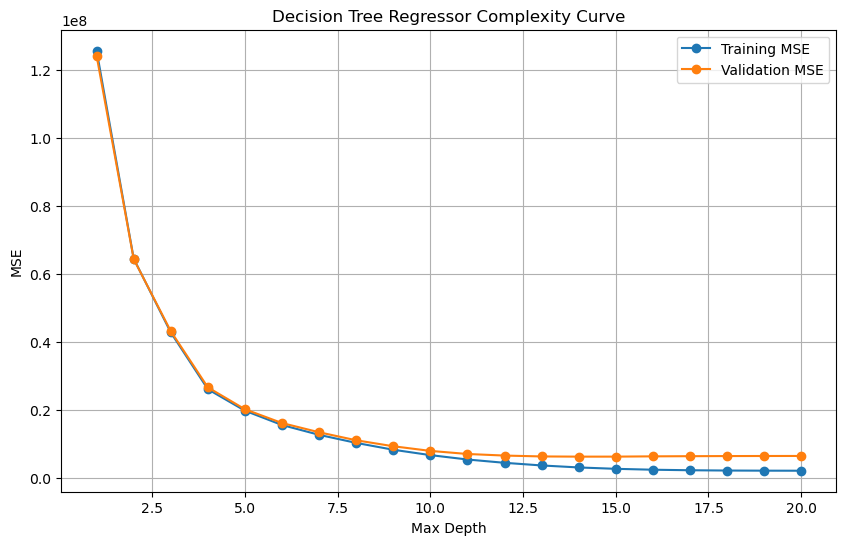

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(depth_values, training_mse_values, marker="o", label="Training MSE")
plt.plot(depth_values, validation_mse_values, marker="o", label="Validation MSE")

plt.title("Decision Tree Regressor Complexity Curve")
plt.xlabel("Max Depth")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

plt.show()

### Elbow Analysis

The complexity curve shows that the Training MSE decreases continuously as `max_depth` increases. This is expected because deeper trees can fit the training data more closely.

The Validation MSE also decreases at first, but it reaches its lowest value around `max_depth = 14`. After this point, the Validation MSE starts to increase slightly while the Training MSE continues to decrease.

This indicates that the model begins to overfit after `max_depth = 14`. Therefore, we would choose `max_depth = 14` for the production model, because it gives the lowest Validation MSE before the validation performance starts to get worse.

# SECTION D

In [45]:
# Section D - Imports

import time
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error

In [46]:
# -----------------------------
# Sklearn Decision Tree Classifier
# -----------------------------

start_time = time.time()

dt_classifier_params = {
    "max_depth": [5, 8, 12],
    "min_samples_leaf": [1, 5, 10]
}

sklearn_dt_classifier_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_classifier_params,
    scoring="accuracy",
    cv=3,
    n_jobs=-1
)

sklearn_dt_classifier_grid.fit(X_train_encoded, y_train_class)

sklearn_dt_classifier = sklearn_dt_classifier_grid.best_estimator_

sklearn_dt_classifier_val_pred = sklearn_dt_classifier.predict(X_val_encoded)
sklearn_dt_classifier_test_pred = sklearn_dt_classifier.predict(X_test_encoded)

sklearn_dt_classifier_val_accuracy = accuracy_score(y_val_class, sklearn_dt_classifier_val_pred)
sklearn_dt_classifier_test_accuracy = accuracy_score(y_test_class, sklearn_dt_classifier_test_pred)

sklearn_dt_classifier_runtime = time.time() - start_time

print("Sklearn Decision Tree Classifier")
print("Best Parameters:", sklearn_dt_classifier_grid.best_params_)
print("Validation Accuracy:", sklearn_dt_classifier_val_accuracy)
print("Test Accuracy:", sklearn_dt_classifier_test_accuracy)
print("Runtime:", sklearn_dt_classifier_runtime, "seconds")

Sklearn Decision Tree Classifier
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 1}
Validation Accuracy: 0.499
Test Accuracy: 0.5022334822321488
Runtime: 2.9598002433776855 seconds


The sklearn Decision Tree Classifier achieved about 50% accuracy, which is close to the scratch-built Decision Tree Classifier.  
This is expected because the `condition` target is imbalanced, so both models perform close to the majority-class baseline.

In [47]:
# -----------------------------
# Sklearn Random Forest Classifier
# -----------------------------

start_time = time.time()

rf_classifier_params = {
    "n_estimators": [30, 50],
    "max_depth": [8, 12],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt"]
}

sklearn_rf_classifier_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_classifier_params,
    scoring="accuracy",
    cv=3,
    n_jobs=-1
)

sklearn_rf_classifier_grid.fit(X_train_encoded, y_train_class)

sklearn_rf_classifier = sklearn_rf_classifier_grid.best_estimator_

sklearn_rf_classifier_val_pred = sklearn_rf_classifier.predict(X_val_encoded)
sklearn_rf_classifier_test_pred = sklearn_rf_classifier.predict(X_test_encoded)

sklearn_rf_classifier_val_accuracy = accuracy_score(y_val_class, sklearn_rf_classifier_val_pred)
sklearn_rf_classifier_test_accuracy = accuracy_score(y_test_class, sklearn_rf_classifier_test_pred)

sklearn_rf_classifier_runtime = time.time() - start_time

print("Sklearn Random Forest Classifier")
print("Best Parameters:", sklearn_rf_classifier_grid.best_params_)
print("Validation Accuracy:", sklearn_rf_classifier_val_accuracy)
print("Test Accuracy:", sklearn_rf_classifier_test_accuracy)
print("Runtime:", sklearn_rf_classifier_runtime, "seconds")

Sklearn Random Forest Classifier
Best Parameters: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 50}
Validation Accuracy: 0.49993333333333334
Test Accuracy: 0.5035002333488899
Runtime: 11.072688102722168 seconds


In [48]:
# -----------------------------
# Sklearn Decision Tree Regressor
# -----------------------------

start_time = time.time()

dt_regressor_params = {
    "max_depth": [8, 12, 14, 16],
    "min_samples_leaf": [1, 5, 10]
}

sklearn_dt_regressor_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_regressor_params,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1
)

sklearn_dt_regressor_grid.fit(X_train_encoded, y_train_reg)

sklearn_dt_regressor = sklearn_dt_regressor_grid.best_estimator_

sklearn_dt_regressor_val_pred = sklearn_dt_regressor.predict(X_val_encoded)
sklearn_dt_regressor_test_pred = sklearn_dt_regressor.predict(X_test_encoded)

sklearn_dt_regressor_val_mse = mean_squared_error(y_val_reg, sklearn_dt_regressor_val_pred)
sklearn_dt_regressor_test_mse = mean_squared_error(y_test_reg, sklearn_dt_regressor_test_pred)

sklearn_dt_regressor_runtime = time.time() - start_time

print("Sklearn Decision Tree Regressor")
print("Best Parameters:", sklearn_dt_regressor_grid.best_params_)
print("Validation MSE:", sklearn_dt_regressor_val_mse)
print("Test MSE:", sklearn_dt_regressor_test_mse)
print("Runtime:", sklearn_dt_regressor_runtime, "seconds")

Sklearn Decision Tree Regressor
Best Parameters: {'max_depth': 16, 'min_samples_leaf': 10}
Validation MSE: 6169085.612199953
Test MSE: 6172181.506733121
Runtime: 3.805265426635742 seconds


In [49]:

# Sklearn Random Forest Regressor


start_time = time.time()

rf_regressor_params = {
    "n_estimators": [30, 50],
    "max_depth": [8, 12],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt"]
}

sklearn_rf_regressor_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_regressor_params,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1
)

sklearn_rf_regressor_grid.fit(X_train_encoded, y_train_reg)

sklearn_rf_regressor = sklearn_rf_regressor_grid.best_estimator_

sklearn_rf_regressor_val_pred = sklearn_rf_regressor.predict(X_val_encoded)
sklearn_rf_regressor_test_pred = sklearn_rf_regressor.predict(X_test_encoded)

sklearn_rf_regressor_val_mse = mean_squared_error(y_val_reg, sklearn_rf_regressor_val_pred)
sklearn_rf_regressor_test_mse = mean_squared_error(y_test_reg, sklearn_rf_regressor_test_pred)

sklearn_rf_regressor_runtime = time.time() - start_time

print("Sklearn Random Forest Regressor")
print("Best Parameters:", sklearn_rf_regressor_grid.best_params_)
print("Validation MSE:", sklearn_rf_regressor_val_mse)
print("Test MSE:", sklearn_rf_regressor_test_mse)
print("Runtime:", sklearn_rf_regressor_runtime, "seconds")

Sklearn Random Forest Regressor
Best Parameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 50}
Validation MSE: 5016213.343522188
Test MSE: 4870057.021106823
Runtime: 9.39411187171936 seconds


In [59]:
comparison_results = pd.DataFrame({
    "Model": [
        "Decision Tree Classifier",
        "Random Forest Classifier",
        "Decision Tree Regressor",
        "Random Forest Regressor"
    ],
    "Scratch Metric": [
        dt_classifier_test_accuracy,
        rf_classifier_test_accuracy,
        dt_regressor_test_mse,
        rf_regressor_test_mse
    ],
    "Sklearn Metric": [
        sklearn_dt_classifier_test_accuracy,
        sklearn_rf_classifier_test_accuracy,
        sklearn_dt_regressor_test_mse,
        sklearn_rf_regressor_test_mse
    ],
    "Metric Type": [
        "Accuracy",
        "Accuracy",
        "MSE",
        "MSE"
    ],
    "Scratch Runtime": [
        dt_classifier_runtime,
        rf_classifier_runtime,
        dt_regressor_runtime,
        rf_regressor_runtime
    ],
    "Sklearn Runtime": [
        sklearn_dt_classifier_runtime,
        sklearn_rf_classifier_runtime,
        sklearn_dt_regressor_runtime,
        sklearn_rf_regressor_runtime
    ]
})

comparison_results

,Model,Scratch Metric,Sklearn Metric,Metric Type,Scratch Runtime,Sklearn Runtime
0,Decision Tree Classifier,5.002333e-01,5.022335e-01,Accuracy,1748.667594,2.959800
1,Random Forest Classifier,4.994333e-01,5.035002e-01,Accuracy,303.466532,11.072688
2,Decision Tree Regressor,1.069577e+07,6.172182e+06,MSE,9.177799,3.805265
3,Random Forest Regressor,1.531949e+07,4.870057e+06,MSE,10.891617,9.394112


### Comparison Discussion

For the classification models, the scratch-built models and the sklearn models achieved very similar accuracy values, around 50%. This is reasonable because the `condition` target is imbalanced, and the class `Good` appears very frequently in the dataset. Therefore, the models perform close to the majority-class baseline.

For the regression models, the sklearn models achieved much lower MSE values than the scratch-built models. This means that the sklearn models predicted vehicle prices more accurately.

The sklearn models were also generally faster than the scratch-built models. A possible explanation is that sklearn implementations are highly optimized, while our scratch-built models use simpler logic and loops. In addition, our scratch-built regression tree uses a limited number of thresholds, while sklearn uses more efficient split-searching methods.

In [61]:
# Random Forest Regressor - Average vs Median prediction

# Convert test data to NumPy to avoid feature-name warnings
X_test_array = X_test_encoded.to_numpy()

# Average prediction: default sklearn prediction
rf_average_predictions = sklearn_rf_regressor.predict(X_test_encoded)
rf_average_mse = mean_squared_error(y_test_reg, rf_average_predictions)

# Median prediction: calculate median from individual tree predictions
all_tree_predictions = np.array([
    tree.predict(X_test_array)
    for tree in sklearn_rf_regressor.estimators_
])

rf_median_predictions = np.median(all_tree_predictions, axis=0)
rf_median_mse = mean_squared_error(y_test_reg, rf_median_predictions)

print("Random Forest Regressor - Average Test MSE:", rf_average_mse)
print("Random Forest Regressor - Median Test MSE:", rf_median_mse)

Random Forest Regressor - Average Test MSE: 4870057.021106823
Random Forest Regressor - Median Test MSE: 4819758.425593684


### Average vs Median Discussion

In this part, we compared two ways to combine the predictions of the trees in the Random Forest Regressor: average and median.

The average method is the default method used by sklearn. However, in our results, using the median gave a slightly lower Test MSE than using the average.

This means that the median prediction performed a little better for predicting the car prices. One possible reason is that the median is less affected by extreme predictions from some trees. For example, if one tree predicts a price that is much higher or much lower than the others, the average can be affected by it more than the median.

Still, the difference between the average MSE and the median MSE was small, so both methods gave similar results overall.

# SECTION E

In [62]:
# -----------------------------
# Feature Importance - Random Forest Regressor
# -----------------------------

rf_importances = sklearn_rf_regressor.feature_importances_
feature_names = X_train_encoded.columns

rf_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

rf_feature_importance.head(10)

,Feature,Importance
4,engine_hp,0.347825
2,year,0.206636
15,vehicle_age,0.132434
3,mileage,0.126881
17,brand_popularity,0.063170
0,make,0.050512
11,owner_count,0.026264
16,mileage_per_year,0.016311
1,model,0.013675
12,accident_history,0.007629


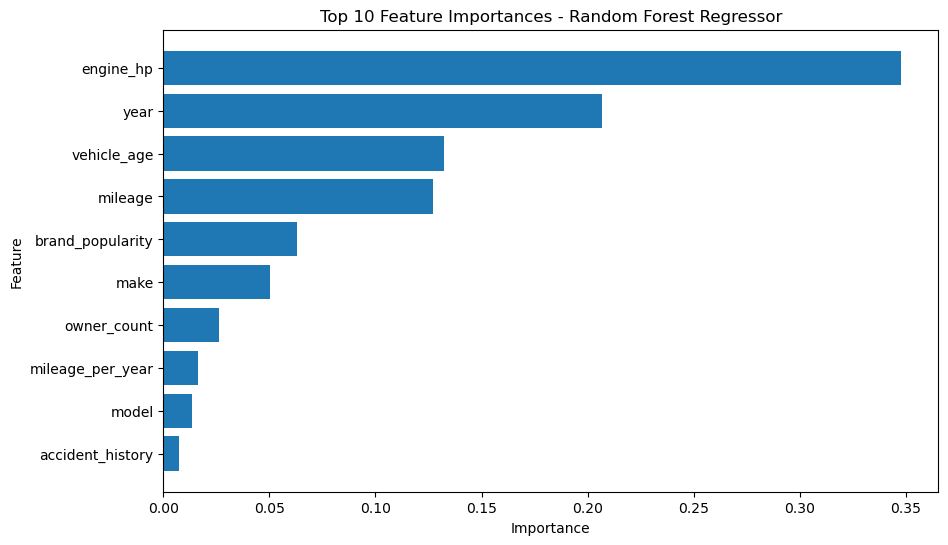

In [63]:
plt.figure(figsize=(10, 6))

top_rf_features = rf_feature_importance.head(10)

plt.barh(top_rf_features["Feature"], top_rf_features["Importance"])
plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances - Random Forest Regressor")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Model Reasoning

The Random Forest Regressor showed that `engine_hp` was the most important feature for predicting vehicle price.

This makes sense because cars with stronger engines are often more expensive. Other important features were `year`, `vehicle_age`, and `mileage`, which are also logical because newer cars and cars with lower mileage usually have higher prices.

In [64]:
# -----------------------------
# Failure Analysis
# -----------------------------

test_predictions = sklearn_rf_regressor.predict(X_test_encoded)

failure_df = X_test.copy()
failure_df["Actual Price"] = y_test_reg.values
failure_df["Predicted Price"] = test_predictions
failure_df["Absolute Error"] = np.abs(failure_df["Actual Price"] - failure_df["Predicted Price"])

# Vehicle with the largest prediction error
worst_case = failure_df.sort_values(by="Absolute Error", ascending=False).head(1)

worst_case

,make,model,year,mileage,engine_hp,transmission,fuel_type,drivetrain,body_type,exterior_color,...,owner_count,accident_history,seller_type,trim,vehicle_age,mileage_per_year,brand_popularity,Actual Price,Predicted Price,Absolute Error
94157,Mercedes-Benz,C-Class,2023,24863,380,Manual,Diesel,FWD,Coupe,Black,...,1,Major,Dealer,Sport,2,12431.5,0.039794,33479.22,48030.788723,14551.568723


In [65]:
worst_case.T

,94157
make,Mercedes-Benz
model,C-Class
year,2023
mileage,24863
engine_hp,380
transmission,Manual
fuel_type,Diesel
drivetrain,FWD
body_type,Coupe
exterior_color,Black


### Failure Analysis

The biggest error was for a 2023 Mercedes-Benz C-Class.  
The real price was 33,479.22, but the model predicted 48,030.79.

The model probably predicted a higher price because the car is new, has low mileage, high engine power, and is a Mercedes-Benz.  
However, the car has a major accident history, which can lower its real price. This may be why the model made a large mistake.

In [66]:
# -----------------------------
# Feature Importance - Decision Tree Regressor
# -----------------------------

dt_importances = sklearn_dt_regressor.feature_importances_

dt_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_importances
}).sort_values(by="Importance", ascending=False)

dt_feature_importance.head(10)

,Feature,Importance
4,engine_hp,0.445211
15,vehicle_age,0.272896
2,year,0.190211
3,mileage,0.046809
0,make,0.014253
12,accident_history,0.012245
17,brand_popularity,0.011142
1,model,0.002966
16,mileage_per_year,0.002035
13,seller_type,0.000786


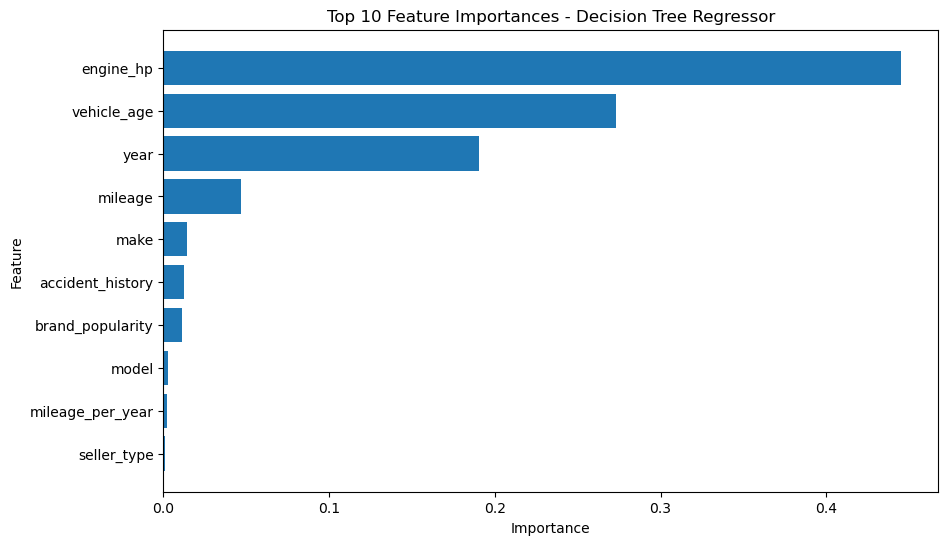

In [67]:
plt.figure(figsize=(10, 6))

top_dt_features = dt_feature_importance.head(10)

plt.barh(top_dt_features["Feature"], top_dt_features["Importance"])
plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances - Decision Tree Regressor")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Decision Tree Feature Importance

The Decision Tree Regressor found similar important features to the Random Forest Regressor.  
The most important feature was also `engine_hp`, followed by `vehicle_age`, `year`, and `mileage`.

This makes sense because engine power, vehicle age, year, and mileage are all related to the market price of a car.

The results are not exactly the same because the Decision Tree is only one tree, while the Random Forest combines many trees. Therefore, the Random Forest importance values are usually more stable.